# 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pickle
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
matplotlib_inline = plt.rcParams.update({'text.parse_math': False})
SEED = 42
print('✅ All imports successful')

✅ All imports successful


# 2. Load Dataset

In [2]:
df = pd.read_csv('fake_job_postings.csv')
print(df.shape)
df.head(2)

(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0


# 3. Inspect Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [4]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [5]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


# 4. Data Cleaning

In [6]:
# Drop irrelevant columns
df.drop(columns=['job_id', 'salary_range'], inplace=True)
print('✅ Dropped: job_id, salary_range')
print('Shape after drop:', df.shape)

✅ Dropped: job_id, salary_range
Shape after drop: (17880, 16)


In [7]:
# Check and remove duplicates
print('Duplicates before:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print('Duplicates after:', df.duplicated().sum())
print('Shape after dedup:', df.shape)

Duplicates before: 288
Duplicates after: 0
Shape after dedup: (17592, 16)


In [8]:
# Fill missing values in text columns with empty string
text_fill_cols = [
    'title', 'location', 'department', 'company_profile',
    'description', 'requirements', 'benefits',
    'employment_type', 'required_experience',
    'required_education', 'industry', 'function'
]
df[text_fill_cols] = df[text_fill_cols].fillna('')
print('✅ Missing text values filled with empty string')
print(df.isnull().sum())

✅ Missing text values filled with empty string
title                  0
location               0
department             0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64


In [9]:
# Clean text — remove HTML tags, URLs, special characters from key text columns
def clean_text(text):
    text = str(text)
    text = re.sub(r'<[^>]+>', ' ', text)        # remove HTML tags
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'&amp;|&lt;|&gt;', ' ', text) # remove HTML entities
    text = re.sub(r'\s+', ' ', text).strip()      # remove extra spaces
    return text

for col in ['title', 'company_profile', 'description', 'requirements', 'benefits']:
    df[col] = df[col].apply(clean_text)

print('✅ HTML tags, URLs, special characters removed')
print('Sample cleaned description:')
print(df['description'].iloc[0][:200])

✅ HTML tags, URLs, special characters removed
Sample cleaned description:
Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curated recipe hub, is currently interviewing full- and part-time unpaid interns to work in a small team o


In [10]:
# Fix data types for numeric columns
df['telecommuting']    = df['telecommuting'].astype(int)
df['has_company_logo'] = df['has_company_logo'].astype(int)
df['has_questions']    = df['has_questions'].astype(int)
df['fraudulent']       = df['fraudulent'].astype(int)
print('✅ Data types fixed')
print(df[['telecommuting','has_company_logo','has_questions','fraudulent']].dtypes)

✅ Data types fixed
telecommuting       int64
has_company_logo    int64
has_questions       int64
fraudulent          int64
dtype: object


#insight

Data cleaning steps: dropped job_id and salary_range (84% missing), removed duplicates, filled missing text with empty strings, removed HTML tags and URLs from text columns, and fixed data types for binary columns.

# 5. EDA

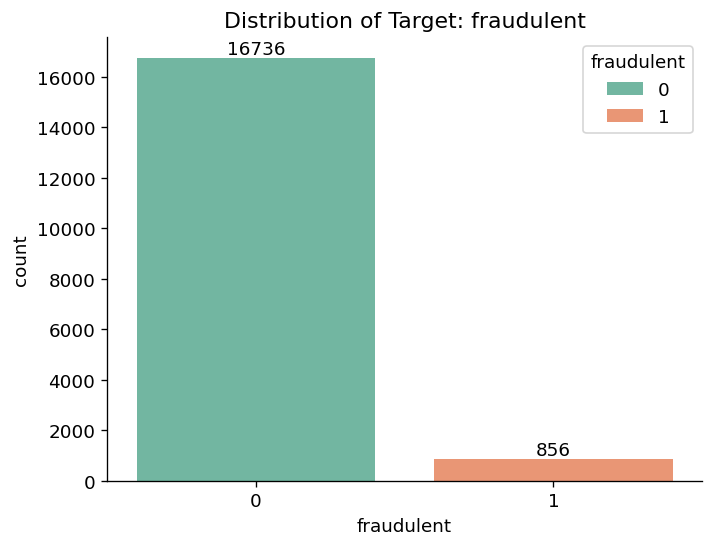

In [11]:
ax = sns.countplot(data=df, x='fraudulent', hue='fraudulent', palette='Set2')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Distribution of Target: fraudulent')
plt.show()

#insight

Dataset is heavily imbalanced: 17,014 real jobs vs 866 fake jobs (4.84% fake rate). SMOTE will be applied after splitting to balance the training data.

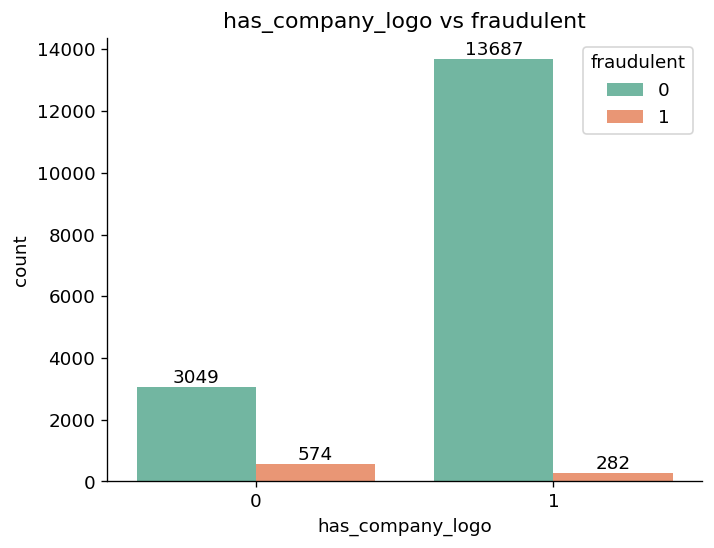

has_company_logo
0    0.158
1    0.020
Name: fraudulent, dtype: float64


In [12]:
ax = sns.countplot(data=df, x='has_company_logo', hue='fraudulent', palette='Set2')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('has_company_logo vs fraudulent')
plt.show()
print(df.groupby('has_company_logo')['fraudulent'].mean().round(3))

#insight

Jobs without a company logo have a 15.9% fake rate vs only 2.0% with a logo. This is the single strongest numeric signal in the dataset.

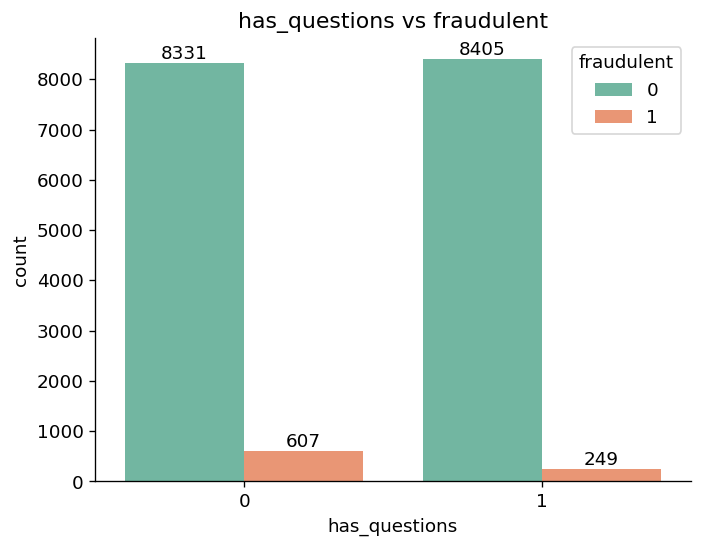

has_questions
0    0.068
1    0.029
Name: fraudulent, dtype: float64


In [13]:
ax = sns.countplot(data=df, x='has_questions', hue='fraudulent', palette='Set2')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('has_questions vs fraudulent')
plt.show()
print(df.groupby('has_questions')['fraudulent'].mean().round(3))

#insight

Jobs without screening questions have a 6.8% fake rate vs 2.8% with questions. Real employers typically screen applicants.

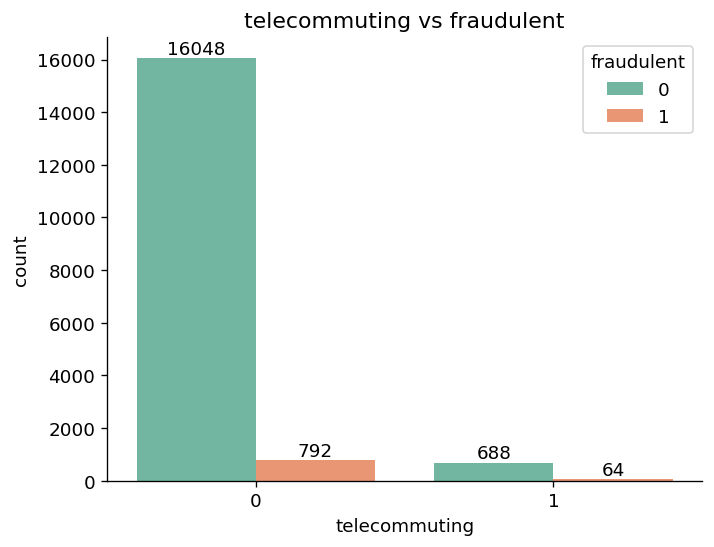

telecommuting
0    0.047
1    0.085
Name: fraudulent, dtype: float64


In [14]:
ax = sns.countplot(data=df, x='telecommuting', hue='fraudulent', palette='Set2')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('telecommuting vs fraudulent')
plt.show()
print(df.groupby('telecommuting')['fraudulent'].mean().round(3))

#insight

Remote/telecommuting jobs have a higher fake rate (8.3%) compared to on-site jobs (4.7%), suggesting scammers favour remote postings.

employment_type
Part-time    0.095
             0.069
Other        0.067
Full-time    0.043
Contract     0.028
Temporary    0.008
Name: fraudulent, dtype: float64


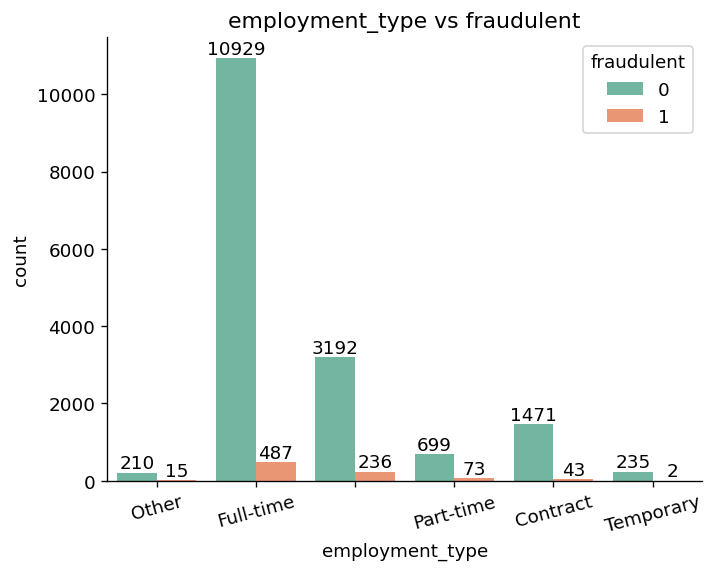

In [15]:
print(df.groupby('employment_type')['fraudulent'].mean().round(3).sort_values(ascending=False))
ax = sns.countplot(data=df, x='employment_type', hue='fraudulent', palette='Set2')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('employment_type vs fraudulent')
plt.xticks(rotation=15)
plt.show()

#insight

Part-time jobs have the highest fake rate (9.3%), followed by Other (6.6%). Full-time roles are relatively safer (4.2%).

In [16]:
print(df.groupby('required_education')['fraudulent'].mean().round(3).sort_values(ascending=False))

required_education
Some High School Coursework          0.741
Certification                        0.115
High School or equivalent            0.085
Master's Degree                      0.075
                                     0.055
Professional                         0.055
Unspecified                          0.045
Doctorate                            0.038
Some College Coursework Completed    0.030
Associate Degree                     0.023
Bachelor's Degree                    0.019
Vocational                           0.000
Vocational - Degree                  0.000
Vocational - HS Diploma              0.000
Name: fraudulent, dtype: float64


#insight

Jobs requiring only 'Some High School Coursework' have a staggering 74.1% fake rate. This is the strongest categorical signal in the entire dataset and will be encoded as a numeric feature.

In [17]:
print(df.groupby('required_experience')['fraudulent'].mean().round(3).sort_values(ascending=False))

required_experience
Executive           0.071
Entry level         0.067
                    0.061
Not Applicable      0.056
Director            0.045
Mid-Senior level    0.030
Internship          0.027
Associate           0.019
Name: fraudulent, dtype: float64


#insight

Executive level and Entry level positions show the highest fake rates (7.1% and 6.6%). Fake jobs target both ends of the experience spectrum.

In [18]:
# Text length comparison Real vs Fake
for col in ['title', 'company_profile', 'description', 'requirements', 'benefits']:
    real_len = df[df.fraudulent==0][col].fillna('').str.len().mean()
    fake_len = df[df.fraudulent==1][col].fillna('').str.len().mean()
    print(f'{col:<20} Real={real_len:.0f} | Fake={fake_len:.0f} | Diff={fake_len-real_len:.0f}')

title                Real=28 | Fake=30 | Diff=2
company_profile      Real=636 | Fake=229 | Diff=-407
description          Real=1206 | Fake=1149 | Diff=-57
requirements         Real=595 | Fake=444 | Diff=-151
benefits             Real=207 | Fake=210 | Diff=3


#insight

Fake jobs have significantly shorter company_profile (-410 chars) and requirements (-151 chars). Real employers provide more detail. These length differences are strong signals and will be added as numeric features.

# 6. Data Leakage Check

In [19]:
# Check for leakage keywords and remove those rows
leak_words = ['fake', 'fraud', 'scam', 'fraudulent']
rows_to_drop = pd.Index([])

for word in leak_words:
    count = df[df['fraudulent']==1]['description'].fillna('').str.contains(word, case=False).sum()
    print(f"'{word}' appears in {count} fake job texts")
    mask = df['description'].fillna('').str.contains(word, case=False, na=False)
    rows_to_drop = rows_to_drop.union(df[mask].index)

df = df.drop(index=rows_to_drop).reset_index(drop=True)
print(f'\n✅ Removed {len(rows_to_drop)} leakage rows. New shape: {df.shape}')

'fake' appears in 0 fake job texts
'fraud' appears in 1 fake job texts
'scam' appears in 0 fake job texts
'fraudulent' appears in 0 fake job texts

✅ Removed 66 leakage rows. New shape: (17526, 16)


# 7. Text Preprocessing

In [20]:
ps = PorterStemmer()
STOPWORDS = set(stopwords.words('english'))

def transform_text(text):
    if not text or str(text).strip() == '': return ''
    text   = str(text).lower()
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t.isalnum()]
    tokens = [t for t in tokens if t not in STOPWORDS and t not in string.punctuation]
    tokens = [ps.stem(t) for t in tokens]
    return ' '.join(tokens)

In [21]:
# Fill missing values
text_cols_to_fill = ['title','required_education','company_profile','description',
                     'requirements','required_experience','function']
df[text_cols_to_fill] = df[text_cols_to_fill].fillna('')

# Combine text columns (benefits excluded — no signal difference between real/fake)
cols = [
    'title',
    'required_education',
    'company_profile',
    'description',
    'requirements',
    'required_experience',
    'function',
]
df['text'] = df[cols].fillna('').agg(' '.join, axis=1)
df['transformed_text'] = df['text'].apply(transform_text)
print('✅ Text preprocessing done')
df['transformed_text'].head(2)

✅ Text preprocessing done


,transformed_text
0,market intern food52 creat groundbreak cook si...
1,custom servic cloud video product 90 second wo...


# 8. Feature Engineering

In [22]:
# Length features — fake jobs have much shorter text in these columns
df['title_length']           = df['title'].str.len()
df['description_length']     = df['description'].str.len()
df['requirements_length']    = df['requirements'].str.len()
df['company_profile_length'] = df['company_profile'].str.len()

# High risk education — 74.1% fake rate for 'Some High School Coursework'
high_risk_edu = ['Some High School Coursework', 'Certification', 'High School or equivalent']
df['is_high_risk_education'] = df['required_education'].isin(high_risk_edu).astype(int)

# Part time flag — 9.3% fake rate
df['is_part_time'] = (df['employment_type'] == 'Part-time').astype(int)


print('✅ Feature engineering done')
print(df[['title_length','description_length','requirements_length',
          'company_profile_length','is_high_risk_education',
          'is_part_time']].head(3))

✅ Feature engineering done
   title_length  description_length  requirements_length  \
0            16                 899                  852   
1            41                1986                 1426   
2            39                 355                 1363   

   company_profile_length  is_high_risk_education  is_part_time  
0                     885                       0             0  
1                     964                       0             0  
2                     872                       0             0  


In [23]:
#combine all numeric features
numeric_cols = [
    'has_company_logo',
    'has_questions',
    'telecommuting',
    'title_length',
    'description_length',
    'requirements_length',
    'company_profile_length',
    'is_high_risk_education',
    'is_part_time'
]

# 9. Word Cloud

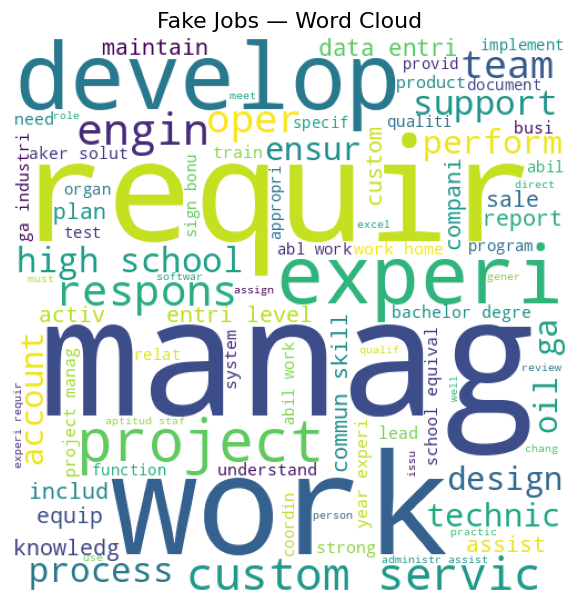

In [24]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

spam_wc = wc.generate(df[df['fraudulent']==1]['transformed_text'].str.cat(sep=' '))
plt.figure(figsize=(15, 6))
plt.imshow(spam_wc)
plt.axis('off')
plt.title('Fake Jobs — Word Cloud')
plt.show()

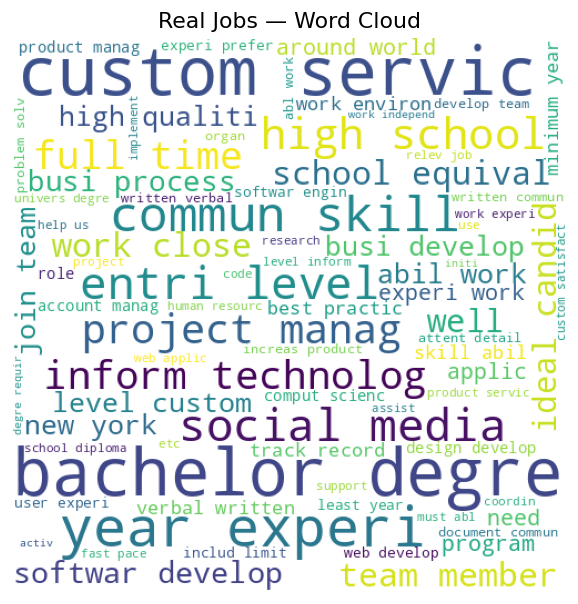

In [25]:
ham_wc = wc.generate(df[df['fraudulent']==0]['transformed_text'].str.cat(sep=' '))
plt.figure(figsize=(15, 6))
plt.imshow(ham_wc)
plt.axis('off')
plt.title('Real Jobs — Word Cloud')
plt.show()

# 10. Train / Test Split

In [26]:
x_text    = df['transformed_text']
x_numeric = df[numeric_cols]
y         = df['fraudulent']

x_train_text, x_test_text, x_train_num, x_test_num, y_train, y_test = train_test_split(
    x_text, x_numeric, y, test_size=0.2, random_state=42
)
print(f'Train fake rate: {y_train.mean():.3f}')
print(f'Test  fake rate: {y_test.mean():.3f}')

Train fake rate: 0.048
Test  fake rate: 0.053


# 11. TF-IDF Vectorization

In [27]:
# ngram_range=(1,2) captures fake phrases like 'work from home', 'earn money', 'no experience'
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

x_train_tfidf = tfidf.fit_transform(x_train_text)
x_test_tfidf  = tfidf.transform(x_test_text)
print(f'TF-IDF shape — Train: {x_train_tfidf.shape}, Test: {x_test_tfidf.shape}')

TF-IDF shape — Train: (14020, 5000), Test: (3506, 5000)


# 12. Combine Numeric + TF-IDF Features

In [28]:
import numpy as np

x_train = np.hstack((x_train_tfidf.toarray(), x_train_num.values))
x_test  = np.hstack((x_test_tfidf.toarray(),  x_test_num.values))

print(f'Combined feature matrix shape — Train: {x_train.shape}, Test: {x_test.shape}')

Combined feature matrix shape — Train: (14020, 5009), Test: (3506, 5009)


# 13. Apply SMOTE on Training Data Only

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Save original y_train before any resampling
y_train_original = y_train.copy()

# Group 1 — combined features
x_train, y_train = smote.fit_resample(x_train, y_train_original)

# Group 2 — tfidf only, use original so sizes match
x_train_text, _ = smote.fit_resample(x_train_tfidf, y_train_original)

print('After SMOTE:')
print(pd.Series(y_train).value_counts())

After SMOTE:
fraudulent
0    13350
1    13350
Name: count, dtype: int64


# 14. Train All Models

In [30]:

models = {
    'Logistic Regression'   : LogisticRegression(max_iter=1000),
    'RandomForestClassifier': RandomForestClassifier(),
    'XGBoost'               : XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=20, random_state=42,
        eval_metric='logloss', verbosity=0
    )
}


results = []

# Train
for model_name, model in models.items():
    model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)
    y_test_pred  = model.predict(x_test)
    results.append({
        'Model'          : model_name,
        'Train Accuracy' : accuracy_score(y_train, y_train_pred),
        'Train Precision': precision_score(y_train, y_train_pred),
        'Train Recall'   : recall_score(y_train, y_train_pred),
        'Train F1'       : f1_score(y_train, y_train_pred),
        'Train ROC-AUC'  : roc_auc_score(y_train, y_train_pred),
        'Test Accuracy'  : accuracy_score(y_test, y_test_pred),
        'Test Precision' : precision_score(y_test, y_test_pred),
        'Test Recall'    : recall_score(y_test, y_test_pred),
        'Test F1'        : f1_score(y_test, y_test_pred),
        'Test ROC-AUC'   : roc_auc_score(y_test, y_test_pred),
    })

# Display combined results
results_df = pd.DataFrame(results).set_index('Model').round(4)
display(results_df)

,Train Accuracy,Train Precision,Train Recall,Train F1,Train ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
Model,,,,,,,,,,
Logistic Regression,0.9539,0.9453,0.9636,0.9543,0.9539,0.9335,0.4322,0.8270,0.5677,0.8833
RandomForestClassifier,1.0000,1.0000,1.0000,1.0000,1.0000,0.9797,0.9597,0.6432,0.7702,0.8209
XGBoost,0.9987,0.9974,1.0000,0.9987,0.9987,0.9763,0.7383,0.8541,0.7920,0.9186


# 15. Evaluation & Visualisation

# **Confusion Matrices**

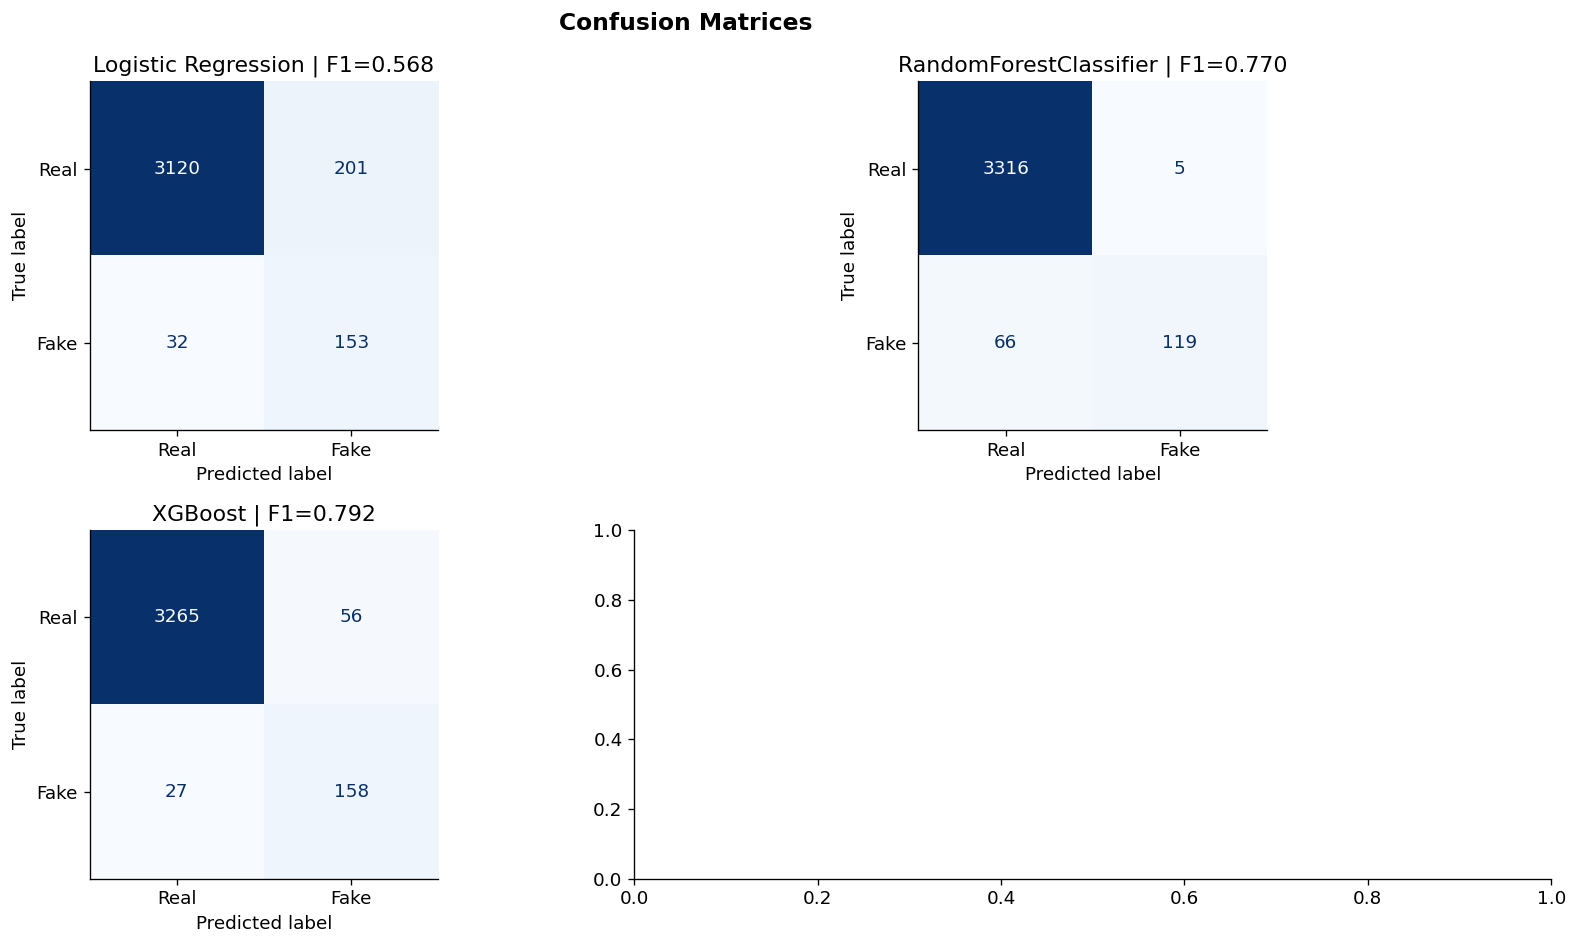

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

for ax, (name, model) in zip(axes.flat, models.items()):
    y_pred = model.predict(x_test)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Real', 'Fake']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} | F1={f1_score(y_test, y_pred):.3f}')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **ROC Curves**

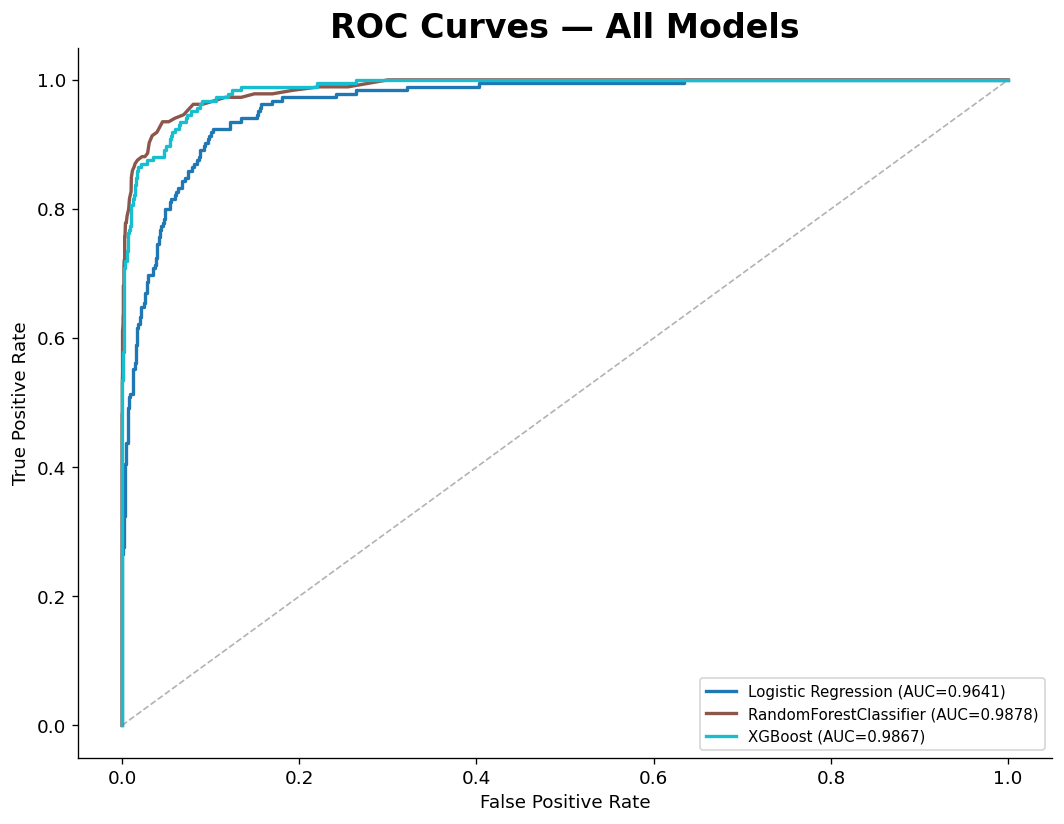

In [32]:
plt.figure(figsize=(9, 7))

for (name, model), color in zip(models.items(), plt.cm.tab10(np.linspace(0, 1, len(models)))):
    y_prob = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={roc_auc_score(y_test, y_prob):.4f})')

plt.plot([0,1],[0,1],'--', color='gray', lw=1, alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=20, fontweight='bold')
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

# **Classification Reports (Top 3 Models)**

In [33]:
# Sort models by Test F1 score from results_df
best_models = results_df.nlargest(3, 'Test F1').index

for name in best_models:
    model = models[name]
    y_pred = model.predict(x_test)
    print(f"{'='*50}")
    print(f'  {name}')
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

  XGBoost
              precision    recall  f1-score   support

        Real       0.99      0.98      0.99      3321
        Fake       0.74      0.85      0.79       185

    accuracy                           0.98      3506
   macro avg       0.87      0.92      0.89      3506
weighted avg       0.98      0.98      0.98      3506

  RandomForestClassifier
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99      3321
        Fake       0.96      0.64      0.77       185

    accuracy                           0.98      3506
   macro avg       0.97      0.82      0.88      3506
weighted avg       0.98      0.98      0.98      3506

  Logistic Regression
              precision    recall  f1-score   support

        Real       0.99      0.94      0.96      3321
        Fake       0.43      0.83      0.57       185

    accuracy                           0.93      3506
   macro avg       0.71      0.88      0.77      3506
weighted avg     

# **Feature Importance — RandomForestClassifier**

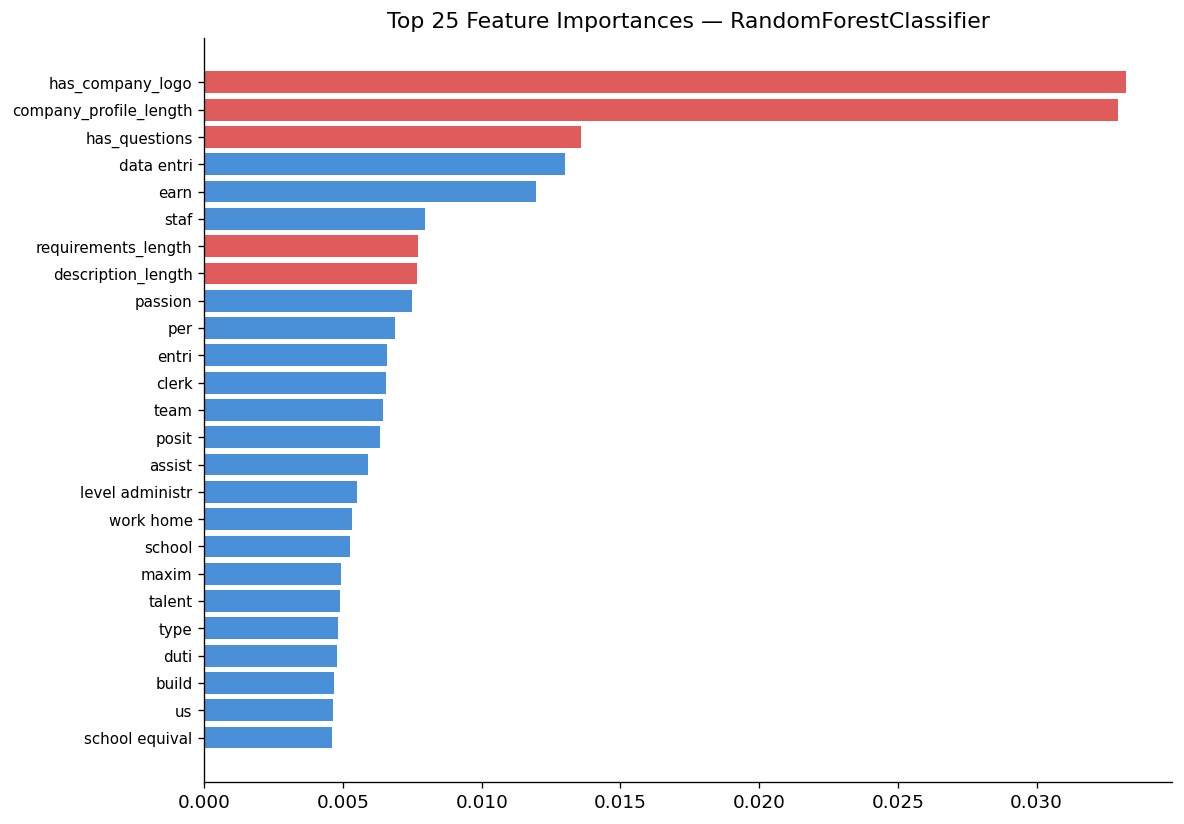

In [34]:
rf_model   = models['RandomForestClassifier']
feat_names = list(tfidf.get_feature_names_out()) + list(numeric_cols)
top_idx    = np.argsort(rf_model.feature_importances_)[::-1][:25]
colors     = ['#E05C5C' if f in numeric_cols else '#4A90D9' for f in np.array(feat_names)[top_idx]]

plt.figure(figsize=(10, 7))
plt.barh(range(25), rf_model.feature_importances_[top_idx][::-1], color=colors[::-1])
plt.yticks(range(25), np.array(feat_names)[top_idx[::-1]], fontsize=9)
plt.title('Top 25 Feature Importances — RandomForestClassifier')
plt.tight_layout()
plt.show()

# **Feature Importance — XGBoost**

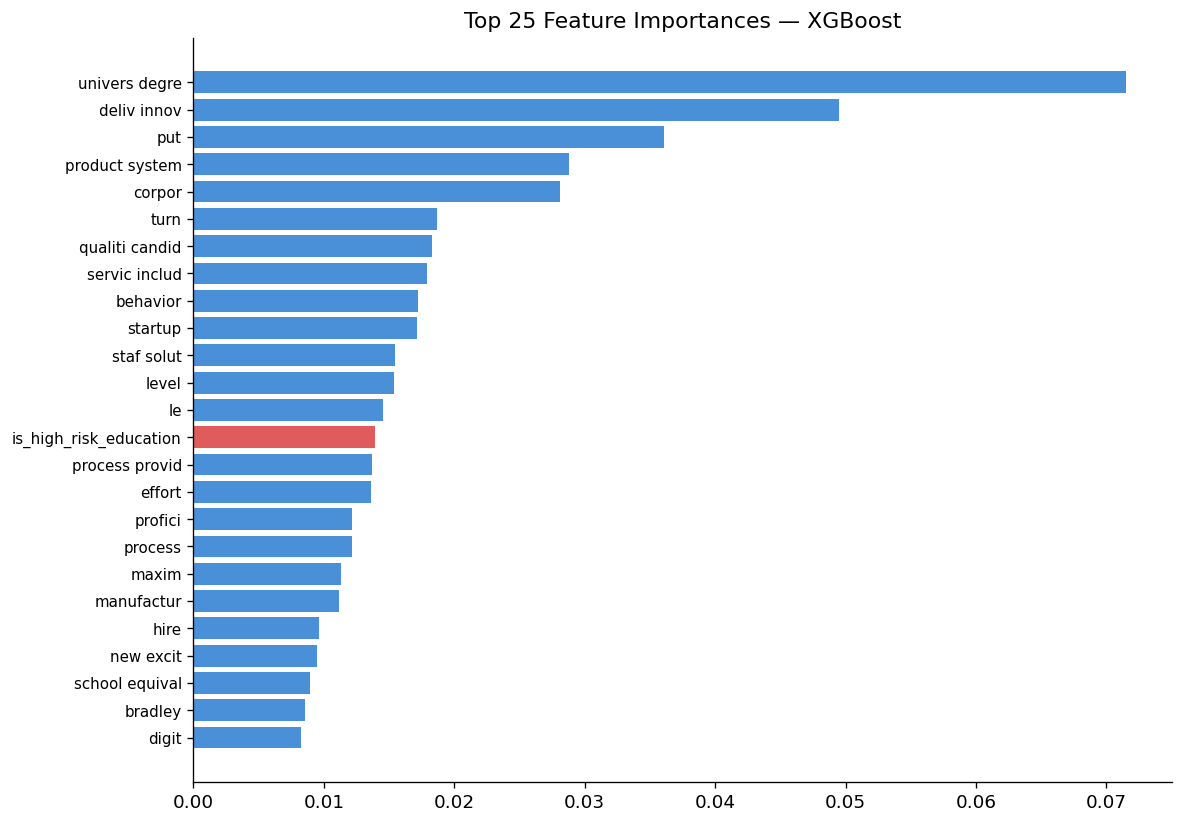

In [35]:
feat_names = list(tfidf.get_feature_names_out()) + list(numeric_cols)
top_idx    = np.argsort(models['XGBoost'].feature_importances_)[::-1][:25]
colors     = ['#E05C5C' if f in numeric_cols else '#4A90D9' for f in np.array(feat_names)[top_idx]]

plt.figure(figsize=(10, 7))
plt.barh(range(25), models['XGBoost'].feature_importances_[top_idx][::-1], color=colors[::-1])
plt.yticks(range(25), np.array(feat_names)[top_idx[::-1]], fontsize=9)
plt.title('Top 25 Feature Importances — XGBoost')
plt.tight_layout()
plt.show()

# **Numeric vs Text Feature Comparison**

In [36]:
# Test with ONLY numeric features (no text)
rf_num_only = RandomForestClassifier()
rf_num_only.fit(x_train_num, y_train_original)
print('Numeric only - Test score:', rf_num_only.score(x_test_num, y_test))

# Test with ONLY text features (no numeric)
rf_text_only = RandomForestClassifier()
rf_text_only.fit(x_train_text, y_train)
print('Text only - Test score:', rf_text_only.score(x_test_tfidf, y_test))

Numeric only - Test score: 0.9634911580148318
Text only - Test score: 0.9791785510553337


In [37]:
for cols in ['title','required_education','company_profile','description','requirements','required_experience']:
    print(f'{cols}:')
    print(df.groupby('fraudulent')[cols].apply(lambda x: x.str.len().mean()))
    print('---')

title:
fraudulent
0    28.183792
1    30.293567
Name: title, dtype: float64
---
required_education:
fraudulent
0    9.676324
1    9.395322
Name: required_education, dtype: float64
---
company_profile:
fraudulent
0    634.495591
1    228.023392
Name: company_profile, dtype: float64
---
description:
fraudulent
0    1202.478676
1    1148.357895
Name: description, dtype: float64
---
requirements:
fraudulent
0    594.981285
1    443.713450
Name: requirements, dtype: float64
---
required_experience:
fraudulent
0    7.605603
1    6.178947
Name: required_experience, dtype: float64
---


# 16. Hyperparameter Tuning

## RandomForest — GridSearchCV

In [38]:
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {
        'n_estimators' : [100, 200],
        'max_depth'    : [None, 20],
        'class_weight' : [{0:1, 1:3}, {0:1, 1:5}]
    },
    cv=3,
    scoring='f1',
    n_jobs=-1
)
gs_rf.fit(x_train, y_train)

best_rf = gs_rf.best_estimator_
y_pred  = best_rf.predict(x_test)

print(gs_rf.best_params_)
print(f'F1: {f1_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=['Real','Fake']))

{'class_weight': {0: 1, 1: 3}, 'max_depth': None, 'n_estimators': 200}
F1: 0.7492
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99      3321
        Fake       0.94      0.62      0.75       185

    accuracy                           0.98      3506
   macro avg       0.96      0.81      0.87      3506
weighted avg       0.98      0.98      0.98      3506



## XGBoost — GridSearchCV

In [39]:
gs_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss', verbosity=0, random_state=42),
    {
        'n_estimators'     : [100, 200],
        'max_depth'        : [4, 6],
        'scale_pos_weight' : [10, 20]
    },
    cv=3,
    scoring='f1',
    n_jobs=-1
)
gs_xgb.fit(x_train, y_train)

best_xgb = gs_xgb.best_estimator_
y_pred   = best_xgb.predict(x_test)

print(gs_xgb.best_params_)
print(f'F1: {f1_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=['Real','Fake']))

{'max_depth': 6, 'n_estimators': 200, 'scale_pos_weight': 10}
F1: 0.8362
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3321
        Fake       0.88      0.80      0.84       185

    accuracy                           0.98      3506
   macro avg       0.93      0.90      0.91      3506
weighted avg       0.98      0.98      0.98      3506



#voting classifier


In [41]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('rf',  best_rf),
        ('xgb', best_xgb),
        ('lr',  models['Logistic Regression']),
    ],
    voting='soft'
)
voting.fit(x_train, y_train)
y_pred_v  = voting.predict(x_test)
y_proba_v = voting.predict_proba(x_test)[:, 1]

print(f'Voting F1:  {f1_score(y_test, y_pred_v):.4f}')
print(f'Voting AUC: {roc_auc_score(y_test, y_proba_v):.4f}')
print(classification_report(y_test, y_pred_v, target_names=['Real','Fake']))

Voting F1:  0.8258
Voting AUC: 0.9890
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3321
        Fake       0.86      0.79      0.83       185

    accuracy                           0.98      3506
   macro avg       0.92      0.89      0.91      3506
weighted avg       0.98      0.98      0.98      3506



## Threshold Tuning — Best Model

In [42]:
y_proba_xgb = best_xgb.predict_proba(x_test)[:, 1]

for threshold in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred_t = (y_proba_xgb >= threshold).astype(int)
    print(
        f'Threshold {threshold:.2f} → '
        f'F1: {f1_score(y_test, y_pred_t):.4f} | '
        f'Recall: {recall_score(y_test, y_pred_t):.4f} | '
        f'Precision: {precision_score(y_test, y_pred_t):.4f}'
    )

Threshold 0.20 → F1: 0.8175 | Recall: 0.8595 | Precision: 0.7794
Threshold 0.25 → F1: 0.8211 | Recall: 0.8432 | Precision: 0.8000
Threshold 0.30 → F1: 0.8172 | Recall: 0.8216 | Precision: 0.8128
Threshold 0.35 → F1: 0.8261 | Recall: 0.8216 | Precision: 0.8306
Threshold 0.40 → F1: 0.8320 | Recall: 0.8162 | Precision: 0.8483
Threshold 0.45 → F1: 0.8315 | Recall: 0.8000 | Precision: 0.8655
Threshold 0.50 → F1: 0.8362 | Recall: 0.8000 | Precision: 0.8757


# 17. Cross Validation

In [50]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# x_train_tfidf and x_train_num still have original 14213 rows
x_train_original = np.hstack((x_train_tfidf.toarray(), x_train_num.values))

print(f'x_train_original shape : {x_train_original.shape}')
print(f'y_train_original shape : {y_train_original.shape}')

all_models = {
    'Logistic Regression'   : LogisticRegression(max_iter=1000),
    'RandomForestClassifier': RandomForestClassifier(**gs_rf.best_params_),
    'XGBoost'               : XGBClassifier(**gs_xgb.best_params_,
                                eval_metric='logloss', verbosity=0),
}

cv_results = []

for name, clf in all_models.items():
    print(f'⏳ Running {name}...')
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', clf)
    ])
    scores = cross_validate(
        pipe, x_train_original, y_train_original,
        cv=cv,
        scoring=['f1', 'roc_auc', 'precision', 'recall'],
        n_jobs=-1
    )
    cv_results.append({
        'Model'    : name,
        'F1'       : scores['test_f1'].mean().round(4),
        'AUC'      : scores['test_roc_auc'].mean().round(4),
        'Precision': scores['test_precision'].mean().round(4),
        'Recall'   : scores['test_recall'].mean().round(4),
    })
    print(f" {name} done — F1: {scores['test_f1'].mean():.4f} | AUC: {scores['test_roc_auc'].mean():.4f}\n")

cv_df = pd.DataFrame(cv_results).set_index('Model')
display(cv_df)

x_train_original shape : (14020, 5009)
y_train_original shape : (14020,)
⏳ Running Logistic Regression...
 Logistic Regression done — F1: 0.5728 | AUC: 0.9711

⏳ Running RandomForestClassifier...
 RandomForestClassifier done — F1: 0.7448 | AUC: 0.9846

⏳ Running XGBoost...
 XGBoost done — F1: 0.8170 | AUC: 0.9787



,F1,AUC,Precision,Recall
Model,,,,
Logistic Regression,0.5728,0.9711,0.4287,0.8642
RandomForestClassifier,0.7448,0.9846,0.9408,0.6164
XGBoost,0.8170,0.9787,0.8500,0.7866


# 18. Save Best Model

In [43]:
# Save the best model, vectorizer and numeric columns list for the app
pickle.dump(tfidf,        open('vectorizer.pkl',   'wb'))
pickle.dump(best_xgb,     open('model.pkl',        'wb'))
pickle.dump(numeric_cols, open('numeric_cols.pkl', 'wb'))
print('✅ Saved: XGBoost | F1=0.84 | Precision=0.88 | Recall=0.80')

✅ Saved: XGBoost | F1=0.84 | Precision=0.88 | Recall=0.80


In [44]:
pickle.dump(voting,      open('model.pkl',        'wb'))

In [45]:
# Save best threshold (replace 0.3 with whatever worked best for you)
best_threshold = 0.3
pickle.dump(best_threshold, open('threshold.pkl', 'wb'))
print(f'✅ Saved threshold: {best_threshold}')

✅ Saved threshold: 0.3


#predict model using example


In [51]:
# ── Load saved pkl files ───────────────────────────────────────────────────────
import pickle
import numpy as np
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

tfidf        = pickle.load(open('vectorizer.pkl',   'rb'))
model        = pickle.load(open('model.pkl',        'rb'))
numeric_cols = pickle.load(open('numeric_cols.pkl', 'rb'))

ps        = PorterStemmer()
STOPWORDS = set(stopwords.words('english'))

def transform_text(text):
    if not text or str(text).strip() == '': return ''
    text   = str(text).lower()
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t.isalnum()]
    tokens = [t for t in tokens if t not in STOPWORDS and t not in string.punctuation]
    tokens = [ps.stem(t) for t in tokens]
    return ' '.join(tokens)

# ── Test Example 1 — Real Job ──────────────────────────────────────────────────
real_job = {
    'title'               : 'Software Engineer',
    'required_education'  : "Bachelor's Degree",
    'company_profile'     : 'Google is a multinational technology company specializing in internet services and products.',
    'description'         : 'We are looking for a skilled software engineer to join our team. You will design and develop scalable systems.',
    'requirements'        : 'Bachelor degree in Computer Science. 3+ years experience in Python or Java. Strong problem solving skills.',
    'required_experience' : 'Mid-Senior level',
    'function'            : 'Engineering',
    'has_company_logo'    : 1,
    'has_questions'       : 1,
    'telecommuting'       : 0,
    'employment_type'     : 'Full-time',
}

# ── Test Example 2 — Fake Job ──────────────────────────────────────────────────
fake_job = {
    'title'               : 'Work From Home Data Entry',
    'required_education'  : 'Some High School Coursework',
    'company_profile'     : '',
    'description'         : 'Earn up to $5000 weekly working from home. No experience needed. Easy work guaranteed income.',
    'requirements'        : '',
    'required_experience' : 'Not Applicable',
    'function'            : '',
    'has_company_logo'    : 0,
    'has_questions'       : 0,
    'telecommuting'       : 1,
    'employment_type'     : 'Part-time',
}

# ── Prediction Function ────────────────────────────────────────────────────────
def predict_job(job):
    # Combine text columns exactly as training
    combined = ' '.join([
        job['title'],
        job['required_education'],
        job['company_profile'],
        job['description'],
        job['requirements'],
        job['required_experience'],
        job['function'],
    ])

    # Preprocess and vectorize
    processed = transform_text(combined)
    text_vec  = tfidf.transform([processed]).toarray()

    # Build numeric features matching numeric_cols order
    numeric_map = {
        'has_company_logo'      : job['has_company_logo'],
        'has_questions'         : job['has_questions'],
        'telecommuting'         : job['telecommuting'],
        'title_length'          : len(job['title']),
        'description_length'    : len(job['description']),
        'requirements_length'   : len(job['requirements']),
        'company_profile_length': len(job['company_profile']),
        'is_high_risk_education': 1 if job['required_education'] in
                                  ['Some High School Coursework','Certification',
                                   'High School or equivalent'] else 0,
        'is_part_time'          : 1 if job['employment_type'] == 'Part-time' else 0,
    }
    num_vec = np.array([[numeric_map[c] for c in numeric_cols]])

    # Predict
    X           = np.hstack([text_vec, num_vec])
    prediction  = model.predict(X)[0]
    probability = model.predict_proba(X)[0]

    label = ' FAKE JOB' if prediction == 1 else 'REAL JOB'
    print(f'Title      : {job["title"]}')
    print(f'Prediction : {label}')
    print(f'Confidence : Real={probability[0]*100:.1f}% | Fake={probability[1]*100:.1f}%')
    print('-' * 50)

# ── Run Both Tests ─────────────────────────────────────────────────────────────
predict_job(real_job)
predict_job(fake_job)

Title      : Software Engineer
Prediction : REAL JOB
Confidence : Real=92.6% | Fake=7.4%
--------------------------------------------------
Title      : Work From Home Data Entry
Prediction :  FAKE JOB
Confidence : Real=3.4% | Fake=96.6%
--------------------------------------------------
